# Diagnosing Sample Quality

MCMC samples are **not** independent — they're correlated, and the chain may not have converged. Blindly using MCMC output without diagnostics is one of the most common pitfalls in computational science.

This notebook covers:
- **Warmup and burn-in**: detecting when the chain reaches equilibrium
- **Autocorrelation and effective sample size (ESS)**: how much independent information your samples contain
- **hamon's built-in diagnostics**: `sample_convergence`, `marginal_entropy`, `energy_balance`
- **When single-chain Gibbs fails**: motivating parallel tempering

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from hamon import SpinNode, Block, SamplingSchedule, sample_states
from hamon.models.ising import IsingEBM, IsingSamplingProgram, hinton_init

## Setup: a 20x20 Ising model

We'll use a ferromagnetic Ising model as our test system, sampling at different temperatures to illustrate easy and hard regimes.

In [2]:
ROWS, COLS = 20, 20
N = ROWS * COLS

# Build model components
nodes = [SpinNode() for _ in range(N)]
edge_list = []
for r in range(ROWS):
    for c in range(COLS):
        idx = r * COLS + c
        if c + 1 < COLS:
            edge_list.append((nodes[idx], nodes[idx + 1]))
        if r + 1 < ROWS:
            edge_list.append((nodes[idx], nodes[idx + COLS]))

# Random biases break the site symmetry, giving each spin a different
# marginal — important for rank-based diagnostics later.
key_bias = jax.random.key(42)
biases = 0.5 * jax.random.normal(key_bias, shape=(N,))
weights = jnp.ones(len(edge_list))

# Graph coloring for blocks
G = nx.grid_2d_graph(ROWS, COLS)
coloring = nx.coloring.greedy_color(G, strategy="DSATUR")
color_groups = [[] for _ in range(max(coloring.values()) + 1)]
for (r, c), color in coloring.items():
    color_groups[color].append(nodes[r * COLS + c])
free_blocks = [Block(g) for g in color_groups]
obs_block = Block(nodes)


def sample_ising(beta_val, n_warmup, n_samples, key):
    """Helper to sample from the 20x20 Ising model at a given temperature."""
    ebm = IsingEBM(nodes, edge_list, biases, weights, jnp.array(beta_val))
    prog = IsingSamplingProgram(ebm, free_blocks, [])
    key, k1, k2 = jax.random.split(key, 3)
    init = hinton_init(k1, ebm, free_blocks, ())
    sched = SamplingSchedule(n_warmup, n_samples, steps_per_sample=1)
    samples = sample_states(k2, prog, sched, init, [], [obs_block])[0]
    return samples


print(f"Model: {ROWS}x{COLS} = {N} spins, {len(edge_list)} edges")
print("Biases: random (std=0.5) to break site symmetry")

Model: 20x20 = 400 spins, 760 edges
Biases: random (std=0.5) to break site symmetry


## Warmup and burn-in

MCMC chains start from an arbitrary initial state. The **warmup** (burn-in) period is the time it takes for the chain to forget its initialization and reach the stationary distribution.

The simplest diagnostic: **trace plots** of summary statistics like magnetization or energy.

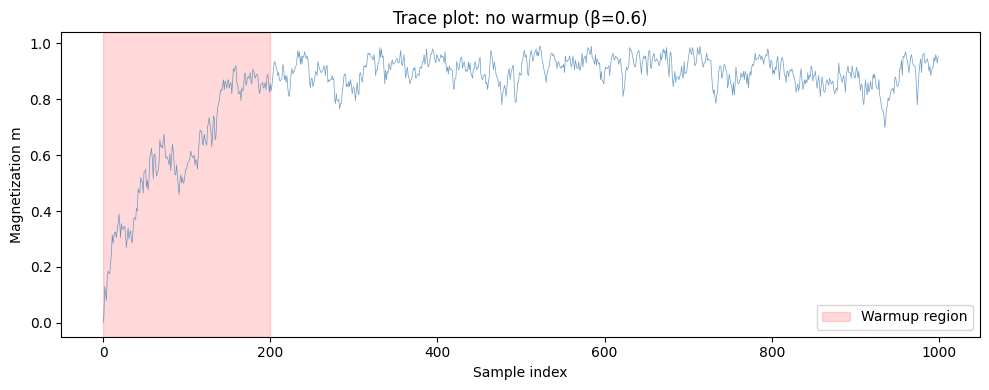

The initial samples are biased by the starting configuration.
Discarding the warmup region removes this bias.


In [3]:
# Sample with NO warmup to see the initial transient
sample_key = jax.random.key(42)
key, subkey = jax.random.split(sample_key)
samples_no_warmup = sample_ising(beta_val=0.6, n_warmup=0, n_samples=1000, key=subkey)

spin_vals = 2 * samples_no_warmup.astype(jnp.float32) - 1
magnetization = jnp.mean(spin_vals, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.array(magnetization), linewidth=0.5, alpha=0.8, color="steelblue")
ax.axvspan(0, 200, alpha=0.15, color="red", label="Warmup region")
ax.set_xlabel("Sample index")
ax.set_ylabel("Magnetization m")
ax.set_title("Trace plot: no warmup (β=0.6)")
ax.legend()
plt.tight_layout()
plt.show()

print("The initial samples are biased by the starting configuration.")
print("Discarding the warmup region removes this bias.")

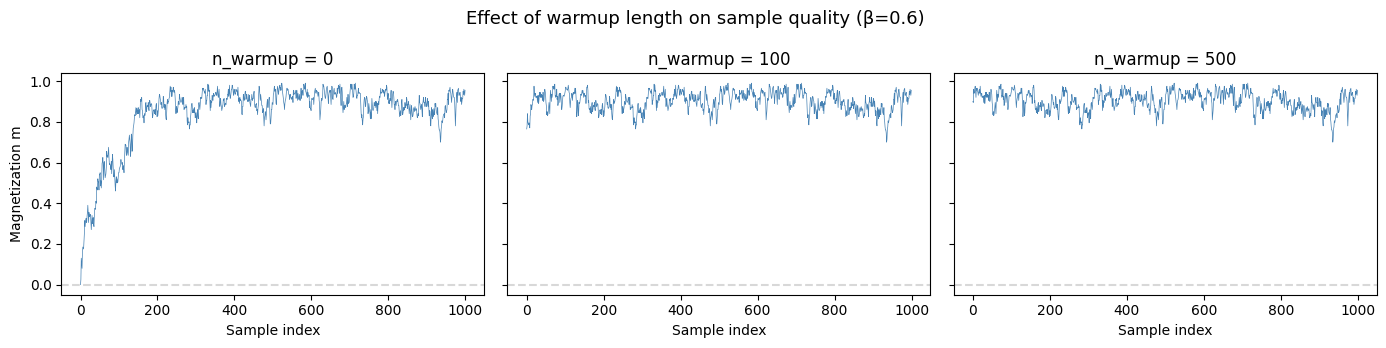

Warmup effect on magnetization statistics:
  n_warmup   mean(first 50)    mean(last 50)    |shift|
--------------------------------------------------------
         0           0.3159           0.9191     0.6032
       100           0.8936           0.9191     0.0255
       500           0.9352           0.9191     0.0161

With no warmup, early samples are biased by the initial state.
With sufficient warmup (500), the chain starts in equilibrium.


In [4]:
# Effect of different warmup lengths
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

warmup_data = {}
for ax, n_warm in zip(axes, [0, 100, 500]):
    samp = sample_ising(0.6, n_warm, 1000, subkey)
    spins = 2 * samp.astype(jnp.float32) - 1
    m = jnp.mean(spins, axis=1)
    ax.plot(np.array(m), linewidth=0.5, color="steelblue")
    ax.set_title(f"n_warmup = {n_warm}")
    ax.set_xlabel("Sample index")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
    warmup_data[n_warm] = np.array(m)

axes[0].set_ylabel("Magnetization m")
fig.suptitle("Effect of warmup length on sample quality (β=0.6)", fontsize=13)
plt.tight_layout()
plt.show()

# Quantitative comparison: first 50 vs last 50 samples
print("Warmup effect on magnetization statistics:")
print(f"{'n_warmup':>10} {'mean(first 50)':>16} {'mean(last 50)':>16} {'|shift|':>10}")
print("-" * 56)
for n_warm in [0, 100, 500]:
    m = warmup_data[n_warm]
    early = np.mean(np.abs(m[:50]))
    late = np.mean(np.abs(m[-50:]))
    print(f"{n_warm:>10} {early:>16.4f} {late:>16.4f} {abs(early - late):>10.4f}")

print("\nWith no warmup, early samples are biased by the initial state.")
print("With sufficient warmup (500), the chain starts in equilibrium.")

## Autocorrelation and effective sample size

Even after warmup, consecutive MCMC samples are **correlated**. The autocorrelation function measures this:

$$C(\tau) = \frac{\text{Cov}(x_t, x_{t+\tau})}{\text{Var}(x_t)}$$

The **effective sample size (ESS)** tells you how many independent samples your correlated chain is worth:

$$\text{ESS} = \frac{n}{1 + 2 \sum_{\tau=1}^{\infty} C(\tau)}$$

Near the critical point ($\beta_c \approx 0.44$), autocorrelation is high and ESS is low — this is **critical slowing down**.

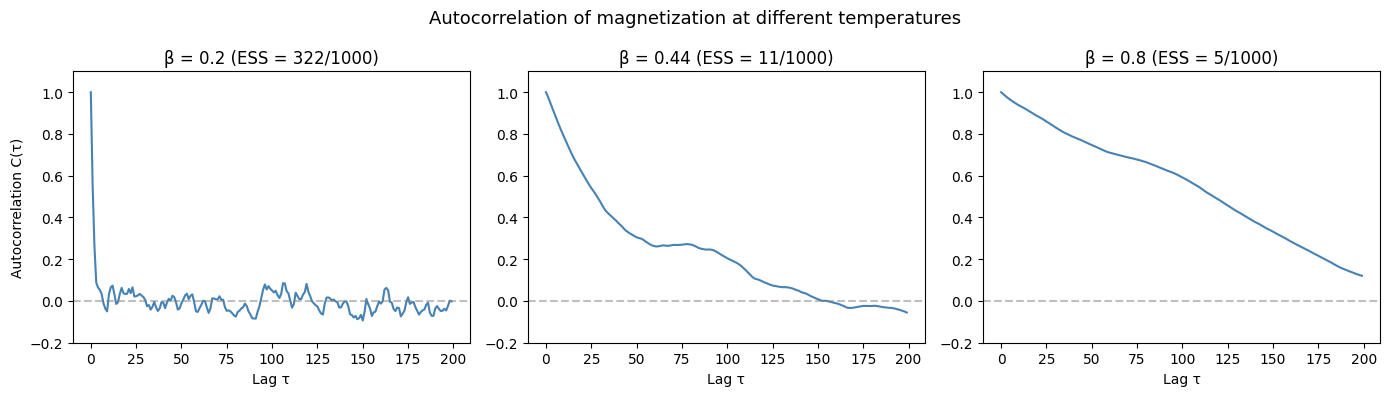

β = 0.2: ESS = 322 out of 2000 samples (16.1% efficiency)
β = 0.44: ESS = 11 out of 2000 samples (0.5% efficiency)
β = 0.8: ESS = 5 out of 2000 samples (0.2% efficiency)


In [5]:
def autocorrelation(x, max_lag=100):
    """Compute the normalized autocorrelation function."""
    x = np.array(x)
    x = x - x.mean()
    n = len(x)
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag)
    acf = np.correlate(x, x, mode="full")[n - 1 : n - 1 + max_lag]
    return acf / (var * n)


def effective_sample_size(acf, n):
    """Estimate ESS from autocorrelation function using initial positive sequence."""
    tau = 1.0
    for i in range(1, len(acf)):
        if acf[i] < 0:
            break
        tau += 2 * acf[i]
    return n / tau


# Compare ACF at different temperatures
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
beta_test = [0.2, 0.44, 0.8]
ess_values = []

for ax, b_val in zip(axes, beta_test):
    samp = sample_ising(b_val, 500, 1000, subkey)
    spins = 2 * samp.astype(jnp.float32) - 1
    m = np.array(jnp.mean(spins, axis=1))

    acf = autocorrelation(m, max_lag=200)
    ess = effective_sample_size(acf, len(m))
    ess_values.append((b_val, ess))

    ax.plot(acf, color="steelblue", linewidth=1.5)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"β = {b_val} (ESS = {ess:.0f}/{len(m)})")
    ax.set_xlabel("Lag τ")
    ax.set_ylim(-0.2, 1.1)

axes[0].set_ylabel("Autocorrelation C(τ)")
fig.suptitle("Autocorrelation of magnetization at different temperatures", fontsize=13)
plt.tight_layout()
plt.show()

for b, ess in ess_values:
    print(
        f"β = {b}: ESS = {ess:.0f} out of 2000 samples ({ess / 2000 * 100:.1f}% efficiency)"
    )

At $\beta = 0.44$ (near the critical point), the autocorrelation decays very slowly and the ESS is much lower than the raw sample count. This means we need many more samples to get the same statistical precision as at high or low temperature.

At $\beta = 0.8$ it's worse because the chain stops exploring entirely. The system is stuck in one of the two magnetization basins (mostly +1 or mostly -1), and single-chain Gibbs can only flip spins one at a time This is exactly the motivation for parallel tempering in notebook 05.

## Marginal convergence with `sample_convergence`

hamon's `diagnostics.sample_convergence` provides an automated convergence check. It splits the samples into quartiles, measures the drift in marginal probabilities between consecutive quartiles, and assesses the rank stability of the most active variables.

**Thresholds for convergence:**
- **CONVERGED**: final drift per variable $\leq 0.01$ AND top-$k$ rank stability (Jaccard) $\geq 0.8$
- **BORDERLINE**: drift $\leq 0.03$ AND Jaccard $\geq 0.64$
- **NEED_MORE**: anything worse

At very high temperature (e.g., $\beta = 0.2$), all marginals are near 0.5, so the top-$k$ ranking is essentially noise — even well-converged samples fail the rank stability test. We use $\beta = 0.3$ below as the "easy" regime: enough ordering for meaningful rank stability, but still fast-mixing.


In [11]:
from hamon.diagnostics import sample_convergence

# Easy regime: moderate temperature (β = 0.3) — fast mixing, some structure
key, subkey = jax.random.split(sample_key)
samp_easy = sample_ising(0.3, 500, 10000, subkey)
report_easy = sample_convergence(samp_easy)

print("=== Easy regime (β = 0.3) ===")
print(f"Status: {report_easy.status}")
print(f"Drifts: {[f'{d:.6f}' for d in report_easy.drifts]}")
print(f"Rank stability: {report_easy.rank_stability:.4f}")

# Hard regime: near critical (β = 0.44) — slow mixing, long correlations
key, subkey = jax.random.split(sample_key)
samp_hard = sample_ising(0.44, 500, 10000, subkey)
report_hard = sample_convergence(samp_hard)

print("\n=== Hard regime (β = 0.44) ===")
print(f"Status: {report_hard.status}")
print(f"Drifts: {[f'{d:.6f}' for d in report_hard.drifts]}")
print(f"Rank stability: {report_hard.rank_stability:.4f}")

print("\nAt β=0.3 the chain mixes well: low drift shows marginals are stable")
print(
    "At β=0.44 (near critical), autocorrelations are long — the chain needs far more samples to converge."
)

=== Easy regime (β = 0.3) ===
Status: CONVERGED
Drifts: ['0.008404', '0.005867', '0.004104']
Rank stability: 0.8750

=== Hard regime (β = 0.44) ===
Status: NEED_MORE
Drifts: ['0.018541', '0.017191', '0.007253']
Rank stability: 0.5000

At β=0.3 the chain mixes well: low drift shows marginals are stable
At β=0.44 (near critical), autocorrelations are long — the chain needs far more samples to converge.


## Marginal entropy

`marginal_entropy` computes the mean per-variable binary entropy, normalized to [0, 1]:
- Near 0: most variables are frozen (all +1 or all -1)
- Near 1: each variable is near 50/50

β = 0.10: entropy = 0.9977
β = 0.30: entropy = 0.9776
β = 0.44: entropy = 0.9060
β = 0.60: entropy = 0.2327
β = 0.70: entropy = 0.2069
β = 1.00: entropy = 0.1392


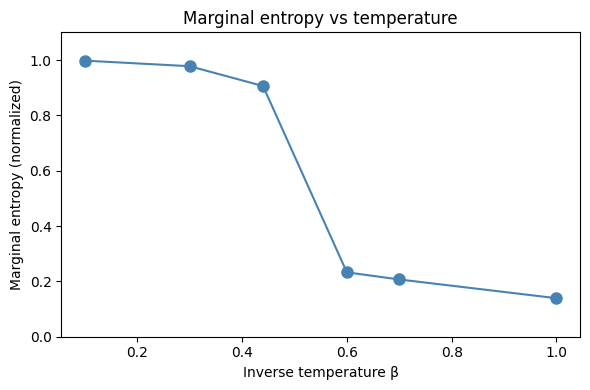

In [7]:
from hamon.diagnostics import marginal_entropy

# Compare entropy at different temperatures
beta_range = [0.1, 0.3, 0.44, 0.6, 0.7, 1.0]
entropies = []

for b_val in beta_range:
    key, subkey = jax.random.split(sample_key)
    samp = sample_ising(b_val, 500, 1000, subkey)
    h = marginal_entropy(samp)
    entropies.append(h)
    print(f"β = {b_val:.2f}: entropy = {h:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(beta_range, entropies, "o-", color="steelblue", markersize=8)
ax.set_xlabel("Inverse temperature β")
ax.set_ylabel("Marginal entropy (normalized)")
ax.set_title("Marginal entropy vs temperature")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

Above β_c ≈ 0.44, the entropy drops because the sampler is trapped, not because the distribution is simple.

The true distribution at β=0.6 has two equally likely states: all +1 and all -1. If you could sample both, each spin would be +1 half the time and -1 half the time — entropy near 1.0. But our single-chain Gibbs sampler gets stuck in whichever basin it started in, so it only ever sees one mode. Every spin looks frozen → entropy near 0.

Low entropy + high β = a red flag that your sampler isn't exploring the full distribution.

## Energy balance

`energy_balance` checks whether bias and coupling energy scales are well-matched, which affects sampling difficulty.

For good sampling with Gibbs/NRPT, you want the ratio near 1 — that means the two energy scales are balanced and both contribute meaningfully to the distribution.

- Ratio >> 1 (couplings dominate): spins lock together in large correlated clusters, creating slow collective modes that are hard for Gibbs to break up
- Ratio << 1 (biases dominate): spins are pinned by their local fields, easy to sample but boring — the model is essentially independent spins
- Ratio ≈ 1: the interesting regime where biases and couplings compete, creating nontrivial structure that's still tractable

In [8]:
from hamon.diagnostics import energy_balance

# Our model has moderate random biases (std=0.5) with unit couplings
edges_array = jnp.array([[nodes.index(e[0]), nodes.index(e[1])] for e in edge_list])
report_ours = energy_balance(biases, edges_array, weights, beta=0.6)
print("Our model (moderate biases):")
print(f"  Bias energy spread: {report_ours.bias_energy_spread:.4f}")
print(f"  Coupling energy/spin: {report_ours.coupling_energy_per_spin:.4f}")
print(f"  Ratio: {report_ours.ratio:.4f}")

# Model with much stronger bias
strong_biases = jax.random.normal(subkey, shape=(N,)) * 4.0
report_biased = energy_balance(strong_biases, edges_array, weights, beta=0.6)
print("\nStrong-bias model:")
print(f"  Bias energy spread: {report_biased.bias_energy_spread:.4f}")
print(f"  Coupling energy/spin: {report_biased.coupling_energy_per_spin:.4f}")
print(f"  Ratio: {report_biased.ratio:.4f}")

Energy balance ratio 3.040 > 2.0: couplings dominate, biases may be irrelevant.


Our model (moderate biases):
  Bias energy spread: 0.7499
  Coupling energy/spin: 2.2800
  Ratio: 3.0403

Strong-bias model:
  Bias energy spread: 6.6470
  Coupling energy/spin: 2.2800
  Ratio: 0.3430


## When single-chain Gibbs fails

The Achilles' heel of single-chain Gibbs sampling is **multimodality**. If the energy landscape has well-separated minima, the chain gets trapped in one mode and can't explore the others.

The 2D Ising ferromagnet below the critical point has two dominant modes: all spins +1 and all spins -1. Let's watch a chain get stuck.

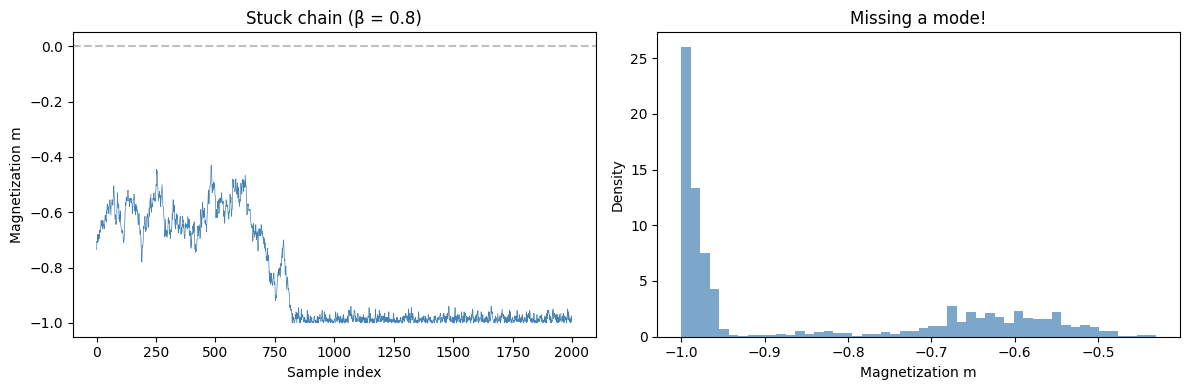

Sign changes in magnetization: 0
The chain is stuck in one mode


In [9]:
# Sample at low temperature — the chain should get stuck
key, subkey = jax.random.split(sample_key)
samp_stuck = sample_ising(beta_val=0.8, n_warmup=500, n_samples=2000, key=subkey)

spins_stuck = 2 * samp_stuck.astype(jnp.float32) - 1
m_stuck = jnp.mean(spins_stuck, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Trace plot
axes[0].plot(np.array(m_stuck), linewidth=0.5, color="steelblue")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Magnetization m")
axes[0].set_title("Stuck chain (β = 0.8)")

# Histogram — should show only one mode
axes[1].hist(np.array(m_stuck), bins=50, density=True, alpha=0.7, color="steelblue")
axes[1].set_xlabel("Magnetization m")
axes[1].set_ylabel("Density")
axes[1].set_title("Missing a mode!")

plt.tight_layout()
plt.show()

# Check: does the chain ever cross m=0?
sign_changes = int(jnp.sum(jnp.abs(jnp.diff(jnp.sign(m_stuck))) > 0))
print(f"Sign changes in magnetization: {sign_changes}")
print(
    f"The chain {'crosses between modes' if sign_changes > 5 else 'is stuck in one mode'}"
)

The chain is stuck in one mode (either all +1 or all -1). It never crosses the energy barrier to reach the other mode. The magnetization histogram shows only one peak instead of the expected two symmetric peaks.

Now we can clearly see why we need **non-reversible parallel tempering**

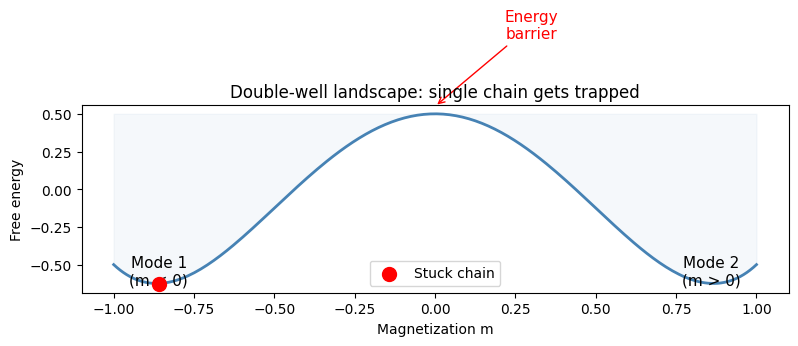

In [10]:
# Schematic: energy landscape with barrier
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-1, 1, 200)
# Double-well potential
E = 2 * x**4 - 3 * x**2 + 0.5
ax.plot(x, E, color="steelblue", linewidth=2)
ax.fill_between(x, E, E.max(), alpha=0.05, color="steelblue")

# Mark the two minima and the barrier
ax.annotate("Mode 1\n(m < 0)", xy=(-0.86, -0.63), fontsize=11, ha="center")
ax.annotate("Mode 2\n(m > 0)", xy=(0.86, -0.63), fontsize=11, ha="center")
ax.annotate(
    "Energy\nbarrier",
    xy=(0, 0.55),
    fontsize=11,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="red"),
    xytext=(0.3, 1.0),
    color="red",
)

# Show stuck chain
ax.scatter([-0.86], [-0.63], s=100, color="red", zorder=5, label="Stuck chain")

ax.set_xlabel("Magnetization m")
ax.set_ylabel("Free energy")
ax.set_title("Double-well landscape: single chain gets trapped")
ax.legend()
plt.tight_layout()
plt.show()

# Summary

- Always **discard warmup** samples — check trace plots to verify equilibration
- **Autocorrelation** measures sample dependence; **ESS** tells you how many independent samples you have
- Near the **critical point**, autocorrelation is high and ESS is low (critical slowing down)
- `sample_convergence` checks marginal drift and rank stability across quartiles
- `marginal_entropy` detects frozen variables; `energy_balance` checks bias/coupling scale mismatch
- **Single-chain Gibbs fails for multimodal distributions** — the chain gets stuck in one mode

Next: **Non-Reversible Parallel Tempering** (Notebook 05) — running chains at different temperatures and swapping states to overcome energy barriers.